Enter x1: 1
Enter y1: 7
Enter x2: 11
Enter y2: 17

--- Digital Differential Analyzer (DDA) ---
Starting point: (1, 7)
Ending point: (11, 17)
Steps: 10
X increment: 1.0
Y increment: 1.0 

x = 1 y = 7 pixels -> (1, 7)
step 1 x = 2.0 y = 8.0 pixels -> (2, 8)
step 2 x = 3.0 y = 9.0 pixels -> (3, 9)
step 3 x = 4.0 y = 10.0 pixels -> (4, 10)
step 4 x = 5.0 y = 11.0 pixels -> (5, 11)
step 5 x = 6.0 y = 12.0 pixels -> (6, 12)
step 6 x = 7.0 y = 13.0 pixels -> (7, 13)
step 7 x = 8.0 y = 14.0 pixels -> (8, 14)
step 8 x = 9.0 y = 15.0 pixels -> (9, 15)
step 9 x = 10.0 y = 16.0 pixels -> (10, 16)
step 10 x = 11.0 y = 17.0 pixels -> (11, 17)


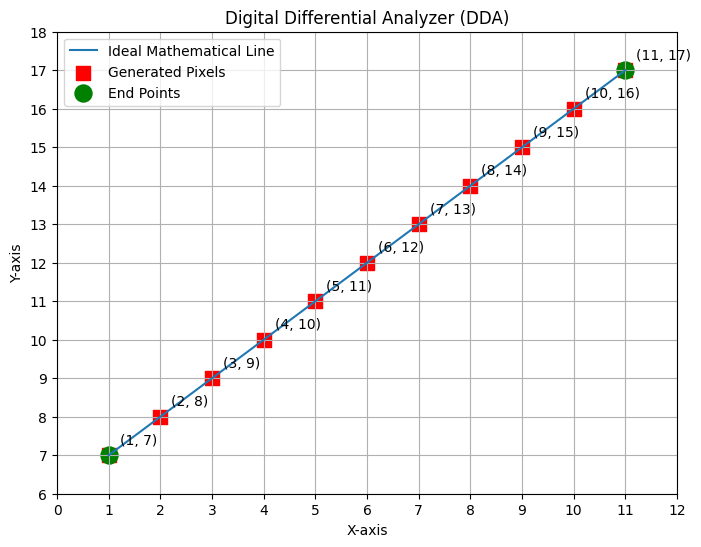

In [1]:
import matplotlib.pyplot as plt

def dda_line(x1, y1, x2, y2):
    pixels = []
    print("\n--- Digital Differential Analyzer (DDA) ---")
    print("Starting point:", (x1, y1))
    print("Ending point:", (x2, y2))

    dx = x2 - x1
    dy = y2 - y1

    # Number of steps = greater of |dx| or |dy|
    steps = max(abs(dx), abs(dy))

    if steps == 0:
        pixels.append((x1, y1))
        print("Both points are same:", (x1, y1))
        return pixels

    # Increment in x and y for each step
    x_inc = dx / steps
    y_inc = dy / steps

    print("Steps:", steps)
    print("X increment:", x_inc)
    print("Y increment:", y_inc, "\n")

    x = x1
    y = y1

    pixels.append((round(x), round(y)))
    print("x =", round(x), "y =", round(y), "pixels ->", (round(x), round(y)))

    for i in range(steps):
        x += x_inc
        y += y_inc

        round_x = round(x)
        round_y = round(y)

        pixels.append((round_x, round_y))
        print(
            "step", i + 1,
            "x =", x,
            "y =", y,
            "pixels ->", (round_x, round_y)
        )

    return pixels


x1 = int(input("Enter x1: "))
y1 = int(input("Enter y1: "))

x2 = int(input("Enter x2: "))
y2 = int(input("Enter y2: "))

# calling function
pixels = dda_line(x1, y1, x2, y2)

# Plotting
x_pixels = [p[0] for p in pixels]
y_pixels = [p[1] for p in pixels]

plt.figure(figsize=(8, 6))

# Ideal mathematical line
plt.plot(
    [x1, x2],
    [y1, y2],
    label="Ideal Mathematical Line"
)

# Generated pixels
plt.scatter(
    x_pixels,
    y_pixels,
    s=100,
    marker="s",
    color="red",
    label="Generated Pixels"
)

# End points
plt.scatter(
    [x1, x2],
    [y1, y2],
    s=150,
    marker="o",
    color="green",
    label="End Points"
)

# Label each generated pixel
for x, y in pixels:
    plt.annotate(
        f"({x}, {y})",
        (x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10
    )

# Axis settings
plt.xticks(range(min(x1, x2) - 1, max(x1, x2) + 2))
plt.yticks(range(min(y1, y2) - 1, max(y1, y2) + 2))
plt.grid(True)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Digital Differential Analyzer (DDA)")
plt.legend()
plt.show()